  PCA REPRODUCIBILITY BENCHMARK (IRIS DATASET)
Scratch Explained Variance Ratio : [0.92461872 0.05306648]
Sklearn Explained Variance Ratio : [0.92461872 0.05306648]
Total Preserved Information      : 97.77%


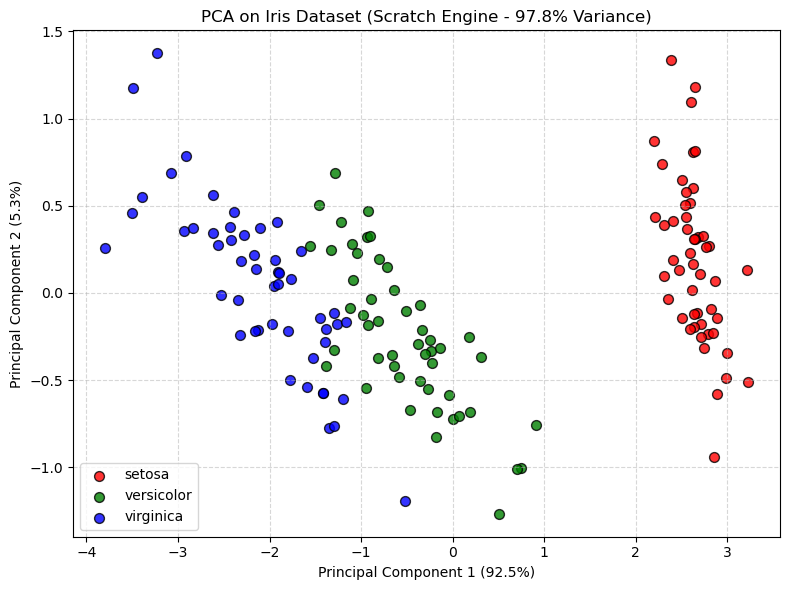

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA as SklearnPCA
import matplotlib.pyplot as plt

# =========================================================================
# 1. First-Principles PCA Engine (NumPy)
# =========================================================================
class PCAScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        n_samples = X.shape[0]
        # Step 1: Zero-centering
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Step 2: Covariance Matrix (1 / (N - 1)) * (X_c^T @ X_c)
        cov_matrix = (1 / (n_samples - 1)) * (X_centered.T @ X_centered)

        # Step 3: Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Step 4: Sort descending
        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvalues = eigenvalues[sorted_idx]
        sorted_eigenvectors = eigenvectors[:, sorted_idx]

        # Step 5: Extract top k components
        total_var = np.sum(sorted_eigenvalues)
        self.explained_variance_ = sorted_eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        self.components = sorted_eigenvectors[:, :self.n_components]
        return self

    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# =========================================================================
# 2. Syllabus Data Loading Pipeline
# =========================================================================
iris = load_iris()
data = iris.data
labels = iris.target
label_names = iris.target_names

iris_df = pd.DataFrame(data, columns=iris.feature_names)

# Fit Scratch PCA
pca_scratch = PCAScratch(n_components=2)
data_reduced = pca_scratch.fit_transform(data)

# Fit Scikit-Learn PCA for benchmark verification
pca_sklearn = SklearnPCA(n_components=2)
data_sklearn = pca_sklearn.fit_transform(data)

# Print Verification Matrix
print("=" * 60)
print("  PCA REPRODUCIBILITY BENCHMARK (IRIS DATASET)")
print("=" * 60)
print(f"Scratch Explained Variance Ratio : {pca_scratch.explained_variance_ratio_}")
print(f"Sklearn Explained Variance Ratio : {pca_sklearn.explained_variance_ratio_}")
print(f"Total Preserved Information      : {np.sum(pca_scratch.explained_variance_ratio_)*100:.2f}%")
print("=" * 60)

# =========================================================================
# 3. Visualization Pipeline (Syllabus Standard)
# =========================================================================
reduced_df = pd.DataFrame(data_reduced, columns=['Principal Component 1', 'Principal Component 2'])
reduced_df['Label'] = labels

plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for i, label in enumerate(np.unique(labels)):
    plt.scatter(
        reduced_df[reduced_df['Label'] == label]['Principal Component 1'],
        reduced_df[reduced_df['Label'] == label]['Principal Component 2'],
        label=label_names[label],
        color=colors[i],
        alpha=0.8,
        edgecolors='k',
        s=50
    )

plt.title(f'PCA on Iris Dataset (Scratch Engine - {np.sum(pca_scratch.explained_variance_ratio_)*100:.1f}% Variance)')
plt.xlabel(f'Principal Component 1 ({pca_scratch.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_scratch.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()